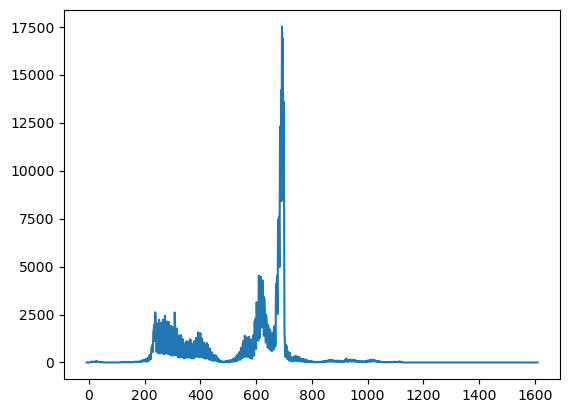

In [2]:
import requests
import json
import numpy as np
import matplotlib.pyplot as plt

# Podatke dobimo z response
# v ozadju je HTTP GET
response = requests.get('https://api.sledilnik.org/api/stats')

# Spravimo jih v json format iz suroave oblike (če ni JSON itak javi error)
res = response.json()

#prešteje, koliko testov je bilo pozitivnih za vsak dan posebej
pozitivni = [res[i]['tests']['positive']['today'] if 'today' in res[i]['tests']['positive'] else 0 for i in range(0,len(res)-1)]
#kateri dan je bil
dan = [res[i]['dayFromStart'] for i in range(0,len(res)-1)]

#izrišemo rezultat
plt.plot(dan,pozitivni)


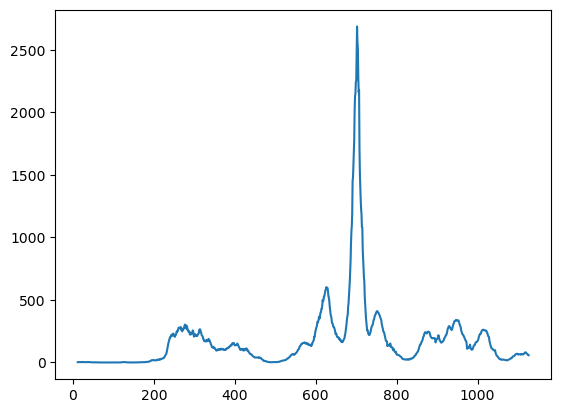

In [3]:
#koliko ljudi je zbolelo v MB za vsak dan posebej
mb_oboleli = [res[i]['statePerRegion']['mb']  for i in range(0,len(res)-1)]
#pretvorimo v numpy array, da lahko naredimo np.diff
mb_oboleli = np.array(mb_oboleli, dtype=float)
#np.diff naredi razliko med 2. in 1. dnem, med 3. in 2. dnem itd.
mb_oboleli = np.diff(mb_oboleli)


#naredimo tedensko povprecje
tedensko_povprecje = [np.average(mb_oboleli[i:i+7]) for i in range(0,len(mb_oboleli))]
#narišemo
plt.plot(tedensko_povprecje)


**What is JSON?**

* **Text-Based Format:**
    * JSON is a lightweight, text-based data-interchange format.
    * It's designed to be easily read and written by humans and easily parsed and generated by machines.
* **Key-Value Pairs:**
    * JSON is built on two structures:
        * Collections of name/value pairs (objects), represented as dictionaries in Python.
        * Ordered lists of values (arrays), represented as lists in Python.
* **Language-Independent:**
    * Although it originated from JavaScript, JSON is language-independent.
    * It's supported by most programming languages, making it ideal for data exchange between different systems.

**How JSON Works:**

* **Syntax:**
    * JSON syntax is simple and straightforward.
    * Objects are enclosed in curly braces `{}`.
    * Arrays are enclosed in square brackets `[]`.
    * Key-value pairs are separated by a colon `:`.
    * Elements within objects and arrays are separated by commas `,`.
    * Strings are enclosed in double quotes `" "`.
    * Numbers, booleans (`true`, `false`), and `null` are also supported.

**Why JSON is Popular:**

* **Simplicity:**
    * Its simple syntax makes it easy to learn and use.
* **Readability:**
    * JSON is human-readable, making it easy to inspect and debug.
* **Lightweight:**
    * JSON files are typically smaller than XML files, leading to faster data transfer.
* **Wide Support:**
    * Most programming languages and web technologies support JSON.
* **API Standard:**
    * It's become the standard data format for web APIs.


In [4]:
#poglejmo 100. vnos (tole skopirajte v https://jsonviewer.stack.hu/ za pregled)
pretty_json = json.dumps(res[100], indent=4)
print(pretty_json)

{
    "dayFromStart": 92,
    "year": 2020,
    "month": 6,
    "day": 3,
    "phase": "F7",
    "performedTestsToDate": 82701,
    "performedTests": 828,
    "positiveTestsToDate": 1477,
    "tests": {
        "performed": {
            "today": 828,
            "toDate": 82701
        },
        "positive": {
            "toDate": 1477
        },
        "regular": {
            "performed": {
                "today": 828,
                "toDate": 82701
            },
            "positive": {
                "toDate": 1477
            }
        },
        "nsApr20": {
            "performed": {
                "toDate": 1368
            },
            "positive": {
                "toDate": 1
            }
        }
    },
    "femaleToDate": 826,
    "maleToDate": 651,
    "cases": {
        "confirmedToDate": 1477,
        "recoveredToDate": 1359,
        "closedToDate": 1468,
        "active": 9,
        "hs": {
            "employeeConfirmedToDate": 168
        },
        "rh":

In [5]:
#pazite, vnosi so lahko NaN!
mb_oboleli[0:100]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,  0.,
        0.,  2.,  4.,  2.,  3.,  6.,  3.,  3.,  3.,  1.,  2.,  4.,  2.,
        7.,  3.,  2.,  4.,  5.,  1.,  4.,  1.,  0.,  2.,  3.,  3.,  4.,
        3.,  2.,  4.,  5.,  4.,  2.,  3.,  1.,  0.,  4.,  3.,  1.,  2.,
        0.,  0.,  1.,  0.,  1.,  1.,  2.,  3.,  0.,  2.,  0.,  0.,  3.,
        1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  0.])